In [870]:
# reading in the libraries and functions that we will need as we do this work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [872]:
clerical= pd.read_csv("C:/Users/preci/Downloads/ProdTime.csv")

clerical.dropna(inplace=True)
clerical.head()

,day,PRODTIME,MONEY,MAIL,WINDOW,CHANGE,CHECKS,MISC,BUS
0,M,128.5,7781,100,886,235,644,56,737
1,T,113.6,7004,110,962,388,589,57,1029
2,W,146.6,7267,61,1342,398,1081,59,830
3,Th,124.3,2129,102,1153,457,891,57,1468
4,F,100.4,4878,45,803,577,537,49,335


In [874]:
clerical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   day       52 non-null     object 
 1   PRODTIME  52 non-null     float64
 2   MONEY     52 non-null     int64  
 3   MAIL      52 non-null     int64  
 4   WINDOW    52 non-null     int64  
 5   CHANGE    52 non-null     int64  
 6   CHECKS    52 non-null     int64  
 7   MISC      52 non-null     int64  
 8   BUS       52 non-null     int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 3.8+ KB


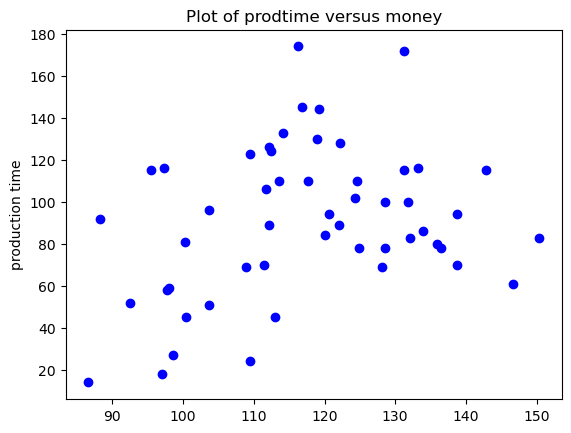

In [876]:
#viewing the data in a scatter plot

plt.scatter(clerical['PRODTIME'],clerical['MAIL'], color="blue")

# Add labels and title
plt.xlabel('')
plt.ylabel('production time')
plt.title('Plot of prodtime versus money')
plt.show()

In [878]:
#Creating a Simple model, using money vs productivity time

In [880]:
#first running a simple linear regression, and finding the fit of the model
# and here it is a linear regression object
clerical_model1= LinearRegression()

#extracting the x as a 2D array
x= clerical[['BUS']]
#extracting y as a 1D series
y= clerical['PRODTIME']


#fitting the model
clerical_model1.fit(x, y)


#making the fitted vs the residual plot
yhat= clerical_model1.predict(x)

# Evaluate the model via the RMSE
rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)

print('Coefficients:', clerical_model.coef_)
print('Intercept:', clerical_model.intercept_)

Root Mean Squared Error: 13.744736129279882
Coefficients: [0.00965335 0.01439482 0.39359972]
Intercept: 75.90412806843882


In [882]:
#fit linear regression model
x2 = sm.add_constant(x)

clerical_model1 = sm.OLS(y, x2).fit()

#view model summary
print(clerical_model1.summary())

                            OLS Regression Results                            
Dep. Variable:               PRODTIME   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     12.67
Date:                Mon, 17 Feb 2025   Prob (F-statistic):           0.000827
Time:                        18:51:23   Log-Likelihood:                -210.06
No. Observations:                  52   AIC:                             424.1
Df Residuals:                      50   BIC:                             428.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        103.3229      4.401     23.476      0.0

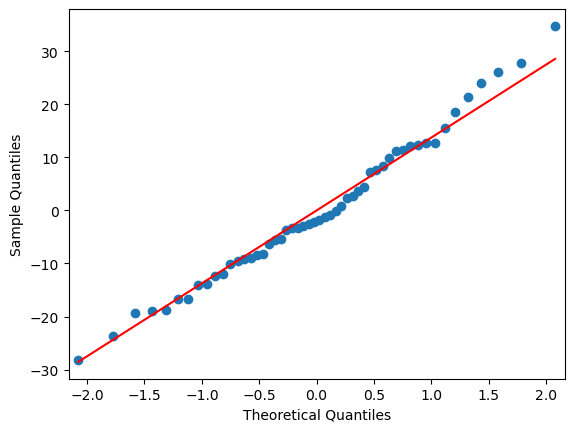

In [884]:
#forming a qqplot to asses the distribution of points

# calculate the residuals 
residuals = y -yhat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(residuals, line ='s') 
# 
py.show() 

In [886]:
#from the plot we can see that there is a slight dip in the bottom left and in the right the values are above the line.

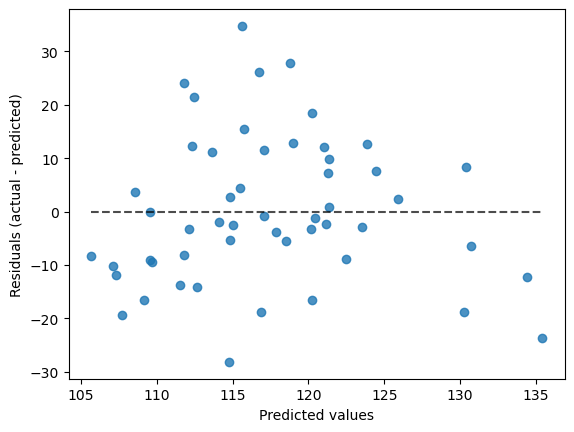

In [888]:
# below makes a residual vs predicted values plot
display = PredictionErrorDisplay(y_true=y, y_pred=yhat)
display.plot()
plt.show()

In [890]:
clerical['BUS_sq']= clerical['BUS']*clerical['BUS']
x = clerical[['BUS', 'BUS_sq']]  
y = clerical['PRODTIME']  

# Create a linear regression model
clerical_model1 = LinearRegression()

# Fit the model on the  data
clerical_model1.fit(x, y)

# Make predictions on the  data
yhat = p_model.predict(x)

# Evaluate the model performance
rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)

# Get the coefficients and intercept
print('Coefficients:',clerical_model1.coef_)
print('Intercept:', clerical_model1.intercept_)


x2 = sm.add_constant(x)

#fit linear regression model
clerical_model1 = sm.OLS(y, x2).fit()

#view model summary
print(clerical_model1.summary())

Root Mean Squared Error: 12.323304116564891
Coefficients: [ 7.83830601e-02 -3.42283911e-05]
Intercept: 82.45302489813409
                            OLS Regression Results                            
Dep. Variable:               PRODTIME   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     13.70
Date:                Mon, 17 Feb 2025   Prob (F-statistic):           1.88e-05
Time:                        18:51:37   Log-Likelihood:                -204.38
No. Observations:                  52   AIC:                             414.8
Df Residuals:                      49   BIC:                             420.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------

In [933]:
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

#creating a Multiple regression model with money, bus, and mail as predictor variables

# first i create a model object to for multiple linear regression
#using day of the number of mail sized items , window payments transacted, and day of the week  

clerical_model= LinearRegression()

x= clerical[['BUS','WINDOW', 'MISC']]
y= clerical['PRODTIME']

#fit the model on the data

clerical_model.fit(x, y)


yhat = clerical_model.predict(x)

# Evaluate the model performance
rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)


print('Coefficients:', clerical_model.coef_)
print('Intercept:', clerical_model.intercept_)


Root Mean Squared Error: 12.093269238953562
Coefficients: [0.00965335 0.01439482 0.39359972]
Intercept: 75.90412806843882


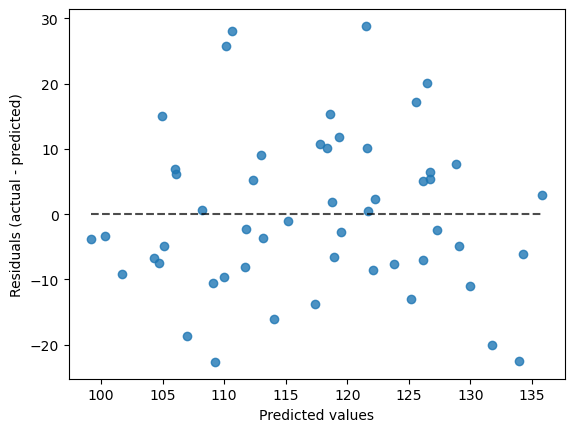

In [936]:
#viewing the residuals vs fitted plot

# below makes a residual plot
display = PredictionErrorDisplay(y_true=y, y_pred=yhat)
display.plot()
plt.show()

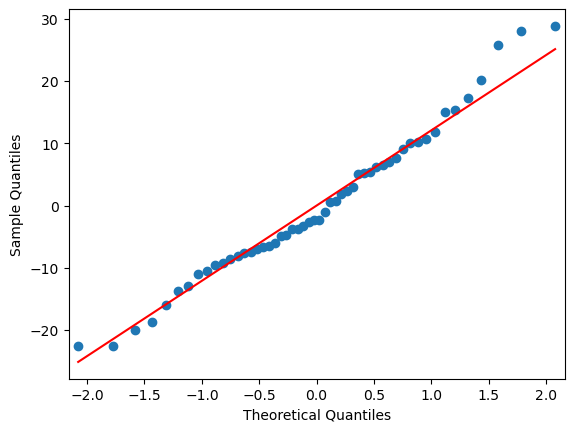

In [940]:
# calculate the residuals 
residuals = y - yhat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(residuals, line ='s') 
# 
py.show() 

In [942]:
#view model summary
x2 = sm.add_constant(x)

model = sm.OLS(y, x2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               PRODTIME   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     9.905
Date:                Mon, 17 Feb 2025   Prob (F-statistic):           3.40e-05
Time:                        18:54:37   Log-Likelihood:                -203.40
No. Observations:                  52   AIC:                             414.8
Df Residuals:                      48   BIC:                             422.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.9041      8.325      9.118      0.0

In [944]:
#condition number is moderate so that could indicates there might be slight multicollinearity

rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 12.093269238953562


In [946]:
#INterpretation , Rsquared, ftest, pvalues, coefficients, rmse

#Our RMSE here is 

In [948]:
# creating a model with more than one predictor variable and interaction
#my predictors will include day of the week as a variable for productivity time

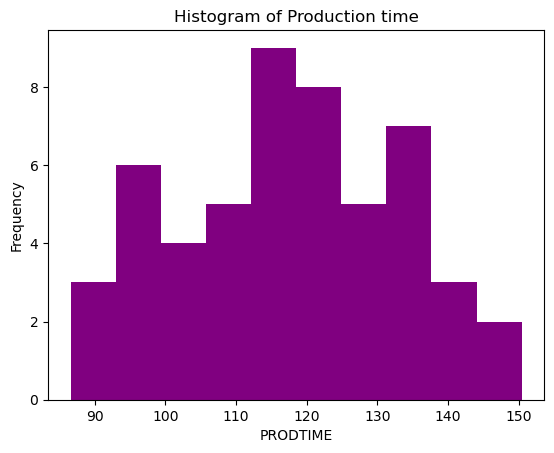

In [950]:
#creating graphical summaries to understand the distribution of the data

plt.hist(clerical['PRODTIME'], color= "purple")
plt.xlabel('PRODTIME')
plt.ylabel('Frequency')
plt.title('Histogram of Production time')
plt.show()


In [952]:
x = clerical[['MONEY','MISC', 'MAIL']]  
y = clerical['PRODTIME']  


# Create a linear regression model
clerical_model2 = LinearRegression()

# Fit the model on the  data
clerical_model2.fit(x, y)

# Make predictions on the  data
yhat = clerical_model2.predict(x)

# Evaluate the model
rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 13.180444700007213


In [954]:
x2 = sm.add_constant(x)

clerical_model2 = sm.OLS(y, x).fit()

#view model summary
print(clerical_model2.summary())

                                 OLS Regression Results                                
Dep. Variable:               PRODTIME   R-squared (uncentered):                   0.971
Model:                            OLS   Adj. R-squared (uncentered):              0.969
Method:                 Least Squares   F-statistic:                              548.7
Date:                Mon, 17 Feb 2025   Prob (F-statistic):                    1.10e-37
Time:                        18:54:38   Log-Likelihood:                         -229.89
No. Observations:                  52   AIC:                                      465.8
Df Residuals:                      49   BIC:                                      471.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [956]:
x = clerical[['MAIL', 'WINDOW', 'MONEY']]  
y = clerical['PRODTIME']  

# Create a linear regression model
clerical_model3 = LinearRegression()

# Fit the model on the  data
clerical_model3.fit(x, y)


# Make predictions on the  data
yhat = clerical_model3.predict(x)
x2 = sm.add_constant(x)

#fit linear regression model
model2 = sm.OLS(y, x2).fit()

# Evaluate the model
rmse = root_mean_squared_error(y, yhat)
print('Root Mean Squared Error:', rmse)

print(model2.summary())

Root Mean Squared Error: 13.340288645362364
                            OLS Regression Results                            
Dep. Variable:               PRODTIME   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     5.288
Date:                Mon, 17 Feb 2025   Prob (F-statistic):            0.00312
Time:                        18:54:38   Log-Likelihood:                -208.51
No. Observations:                  52   AIC:                             425.0
Df Residuals:                      48   BIC:                             432.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

<Axes: ylabel='PRODTIME'>

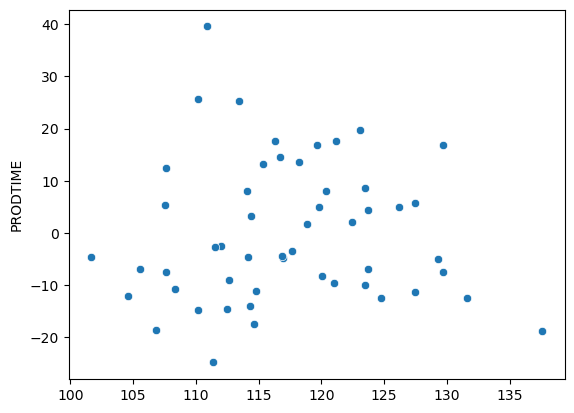

In [958]:
# a look at the residual vs fitted plot
sns.scatterplot(x=yhat, y=y-yhat)